# DAA Lab 1
## Comparative Study of Algorithm Efficiency and Performance Analysis

### Objective

This lab studies the efficiency and performance of different sorting and
Fibonacci algorithms. The algorithms are compared based on execution time,
memory usage, theoretical complexity, and scalability.

### Sorting Algorithms
1. Bubble Sort
2. Insertion Sort
3. Merge Sort
4. Quick Sort

### Fibonacci Algorithms
1. Recursive Fibonacci
2. Iterative Fibonacci
3. Dynamic Programming Fibonacci
   

In [1]:
import time
import tracemalloc
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [15]:
import sys
sys.setrecursionlimit(20000)

Bubble Sort


In [2]:
def bubble_sort(arr):
    a = arr.copy()
    n = len(a)

    for i in range(n - 1):
        swapped = False

        for j in range(n - 1 - i):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True

        if not swapped:
            break

    return a

Insertion Sort

In [3]:
def insertion_sort(arr):
    a = arr.copy()

    for i in range(1, len(a)):
        key = a[i]
        j = i - 1

        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            j -= 1

        a[j + 1] = key

    return a

Merge Sort

In [4]:
def merge_sort(arr):
    a = arr.copy()

    if len(a) <= 1:
        return a

    mid = len(a) // 2

    left = merge_sort(a[:mid])
    right = merge_sort(a[mid:])

    return merge(left, right)


def merge(left, right):
    merged = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])

    return merged

Quick Sort

In [5]:
def quick_sort(arr):
    a = arr.copy()
    quick_sort_helper(a, 0, len(a) - 1)
    return a


def quick_sort_helper(a, low, high):
    if low < high:
        p = partition(a, low, high)

        quick_sort_helper(a, low, p - 1)
        quick_sort_helper(a, p + 1, high)


def partition(a, low, high):
    pivot = a[high]
    i = low - 1

    for j in range(low, high):
        if a[j] <= pivot:
            i += 1
            a[i], a[j] = a[j], a[i]

    a[i + 1], a[high] = a[high], a[i + 1]

    return i + 1

In [6]:
sample = [64, 34, 25, 12, 22, 11, 90]

print("Original:", sample)
print("Bubble Sort:", bubble_sort(sample))
print("Insertion Sort:", insertion_sort(sample))
print("Merge Sort:", merge_sort(sample))
print("Quick Sort:", quick_sort(sample))

Original: [64, 34, 25, 12, 22, 11, 90]
Bubble Sort: [11, 12, 22, 25, 34, 64, 90]
Insertion Sort: [11, 12, 22, 25, 34, 64, 90]
Merge Sort: [11, 12, 22, 25, 34, 64, 90]
Quick Sort: [11, 12, 22, 25, 34, 64, 90]


Recursive Fibonacci

In [7]:
def fib_recursive(n):
    if n <= 1:
        return n

    return fib_recursive(n - 1) + fib_recursive(n - 2)

Iterative Fibonacci

In [8]:
def fib_iterative(n):
    if n <= 1:
        return n

    a, b = 0, 1

    for _ in range(2, n + 1):
        a, b = b, a + b

    return b

Dynamic Programming Fibonacci

In [9]:
def fib_dp(n, memo=None):
    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n <= 1:
        return n

    memo[n] = fib_dp(n - 1, memo) + fib_dp(n - 2, memo)

    return memo[n]

Test Fibonacci

In [10]:
for n in [10, 20, 30, 40]:
    print("n =", n)
    print("Recursive:", fib_recursive(n))
    print("Iterative:", fib_iterative(n))
    print("Dynamic Programming:", fib_dp(n))
    print()

n = 10
Recursive: 55
Iterative: 55
Dynamic Programming: 55

n = 20
Recursive: 6765
Iterative: 6765
Dynamic Programming: 6765

n = 30
Recursive: 832040
Iterative: 832040
Dynamic Programming: 832040

n = 40
Recursive: 102334155
Iterative: 102334155
Dynamic Programming: 102334155



In [11]:
def measure_performance(func, data):
    tracemalloc.start()

    start_time = time.perf_counter()
    result = func(data)
    end_time = time.perf_counter()

    current, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    execution_time = end_time - start_time
    memory_kb = peak_memory / 1024

    return execution_time, memory_kb

In [12]:
def generate_datasets(size):
    random_data = [random.randint(0, 100000) for _ in range(size)]

    sorted_data = sorted(random_data)
    reverse_data = sorted(random_data, reverse=True)

    return {
        "Sorted": sorted_data,
        "Reverse Sorted": reverse_data,
        "Random": random_data
    }

In [13]:
sorting_algorithms = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

In [17]:
input_sizes = [100, 500, 1000, 5000, 10000]

results = []

for size in input_sizes:
    print(f"\nTesting input size: {size}")

    datasets = generate_datasets(size)

    for condition, data in datasets.items():

        print(f"  Condition: {condition}")

        for algorithm_name, algorithm in sorting_algorithms.items():

            print(f"    Running {algorithm_name}...", end=" ")

            start_time = time.perf_counter()

            try:
                tracemalloc.start()

                algorithm(data)

                current, peak_memory = tracemalloc.get_traced_memory()
                tracemalloc.stop()

                execution_time = time.perf_counter() - start_time
                memory_kb = peak_memory / 1024

                results.append({
                    "Input Size": size,
                    "Condition": condition,
                    "Algorithm": algorithm_name,
                    "Execution Time (seconds)": execution_time,
                    "Memory Usage (KB)": memory_kb
                })

                print(f"{execution_time:.4f} sec")

            except RecursionError:
                tracemalloc.stop()

                results.append({
                    "Input Size": size,
                    "Condition": condition,
                    "Algorithm": algorithm_name,
                    "Execution Time (seconds)": None,
                    "Memory Usage (KB)": None
                })

                print("Recursion limit reached")

print("\nExperiment completed!")


Testing input size: 100
  Condition: Sorted
    Running Bubble Sort... 0.0200 sec
    Running Insertion Sort... 0.0000 sec
    Running Merge Sort... 0.0010 sec
    Running Quick Sort... 0.0006 sec
  Condition: Reverse Sorted
    Running Bubble Sort... 0.0006 sec
    Running Insertion Sort... 0.0003 sec
    Running Merge Sort... 0.0006 sec
    Running Quick Sort... 0.0005 sec
  Condition: Random
    Running Bubble Sort... 0.0005 sec
    Running Insertion Sort... 0.0001 sec
    Running Merge Sort... 0.0007 sec
    Running Quick Sort... 0.0005 sec

Testing input size: 500
  Condition: Sorted
    Running Bubble Sort... 0.0008 sec
    Running Insertion Sort... 0.0008 sec
    Running Merge Sort... 0.0042 sec
    Running Quick Sort... 0.1078 sec
  Condition: Reverse Sorted
    Running Bubble Sort... 0.1199 sec
    Running Insertion Sort... 0.0597 sec
    Running Merge Sort... 0.0034 sec
    Running Quick Sort... 0.1739 sec
  Condition: Random
    Running Bubble Sort... 0.1137 sec
    Running


KeyboardInterrupt



In [18]:
print("Number of completed results:", len(results))

Number of completed results: 51


In [19]:
results_df = pd.DataFrame(results)

results_df

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.019995,10993.997070
1,100,Sorted,Insertion Sort,0.000047,0.867188
2,100,Sorted,Merge Sort,0.001018,4.273438
3,100,Sorted,Quick Sort,0.000634,0.867188
4,100,Reverse Sorted,Bubble Sort,0.000592,0.906250
5,100,Reverse Sorted,Insertion Sort,0.000264,0.867188
6,100,Reverse Sorted,Merge Sort,0.000646,3.289062
7,100,Reverse Sorted,Quick Sort,0.000509,0.867188
8,100,Random,Bubble Sort,0.000487,0.906250
9,100,Random,Insertion Sort,0.000144,0.867188


In [20]:
results_df.to_csv("sorting_performance_results.csv", index=False)

print("Sorting results saved successfully.")

Sorting results saved successfully.


In [21]:
results_df = pd.DataFrame(results)

print("Completed sorting experiments:", len(results_df))

results_df.to_csv("sorting_performance_results.csv", index=False)

results_df

Completed sorting experiments: 51


,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.019995,10993.997070
1,100,Sorted,Insertion Sort,0.000047,0.867188
2,100,Sorted,Merge Sort,0.001018,4.273438
3,100,Sorted,Quick Sort,0.000634,0.867188
4,100,Reverse Sorted,Bubble Sort,0.000592,0.906250
5,100,Reverse Sorted,Insertion Sort,0.000264,0.867188
6,100,Reverse Sorted,Merge Sort,0.000646,3.289062
7,100,Reverse Sorted,Quick Sort,0.000509,0.867188
8,100,Random,Bubble Sort,0.000487,0.906250
9,100,Random,Insertion Sort,0.000144,0.867188


In [22]:
fibonacci_algorithms = {
    "Recursive Fibonacci": fib_recursive,
    "Iterative Fibonacci": fib_iterative,
    "Dynamic Programming Fibonacci": fib_dp
}

In [23]:
fib_sizes = [10, 20, 30, 40]

fib_results = []

for n in fib_sizes:
    print(f"Testing n = {n}")

    for algorithm_name, algorithm in fibonacci_algorithms.items():

        tracemalloc.start()

        start_time = time.perf_counter()
        result = algorithm(n)
        end_time = time.perf_counter()

        current, peak_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        fib_results.append({
            "n": n,
            "Algorithm": algorithm_name,
            "Fibonacci Value": result,
            "Execution Time (seconds)": end_time - start_time,
            "Memory Usage (KB)": peak_memory / 1024
        })

        print(f"  {algorithm_name}: {end_time - start_time:.6f} sec")

print("Fibonacci experiment completed!")

Testing n = 10
  Recursive Fibonacci: 0.000016 sec
  Iterative Fibonacci: 0.000010 sec
  Dynamic Programming Fibonacci: 0.000008 sec
Testing n = 20
  Recursive Fibonacci: 0.001144 sec
  Iterative Fibonacci: 0.000009 sec
  Dynamic Programming Fibonacci: 0.000018 sec
Testing n = 30
  Recursive Fibonacci: 0.167761 sec
  Iterative Fibonacci: 0.000021 sec
  Dynamic Programming Fibonacci: 0.000042 sec
Testing n = 40
  Recursive Fibonacci: 20.244503 sec
  Iterative Fibonacci: 0.000026 sec
  Dynamic Programming Fibonacci: 0.000058 sec
Fibonacci experiment completed!


In [24]:
fib_df = pd.DataFrame(fib_results)

fib_df

,n,Algorithm,Fibonacci Value,Execution Time (seconds),Memory Usage (KB)
0,10,Recursive Fibonacci,55,0.000016,8652.068359
1,10,Iterative Fibonacci,55,0.000010,0.085938
2,10,Dynamic Programming Fibonacci,55,0.000008,0.437500
3,20,Recursive Fibonacci,6765,0.001144,0.156250
4,20,Iterative Fibonacci,6765,0.000009,0.132812
5,20,Dynamic Programming Fibonacci,6765,0.000018,0.835938
6,30,Recursive Fibonacci,832040,0.167761,0.822266
7,30,Iterative Fibonacci,832040,0.000021,0.132812
8,30,Dynamic Programming Fibonacci,832040,0.000042,1.945312
9,40,Recursive Fibonacci,102334155,20.244503,8.114258


In [25]:
fib_df.to_csv("fibonacci_performance_results.csv", index=False)

# Complexity Comparison Table

| Algorithm | Best Case | Average Case | Worst Case | Space Complexity |
|---|---|---|---|---|
| Bubble Sort | O(n) | O(n²) | O(n²) | O(1) |
| Insertion Sort | O(n) | O(n²) | O(n²) | O(1) |
| Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) |
| Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) |
| Recursive Fibonacci | O(2ⁿ) | O(2ⁿ) | O(2ⁿ) | O(n) |
| Iterative Fibonacci | O(n) | O(n) | O(n) | O(1) |
| Dynamic Programming Fibonacci | O(n) | O(n) | O(n) | O(n) |

Sorting Execution - Time Graph

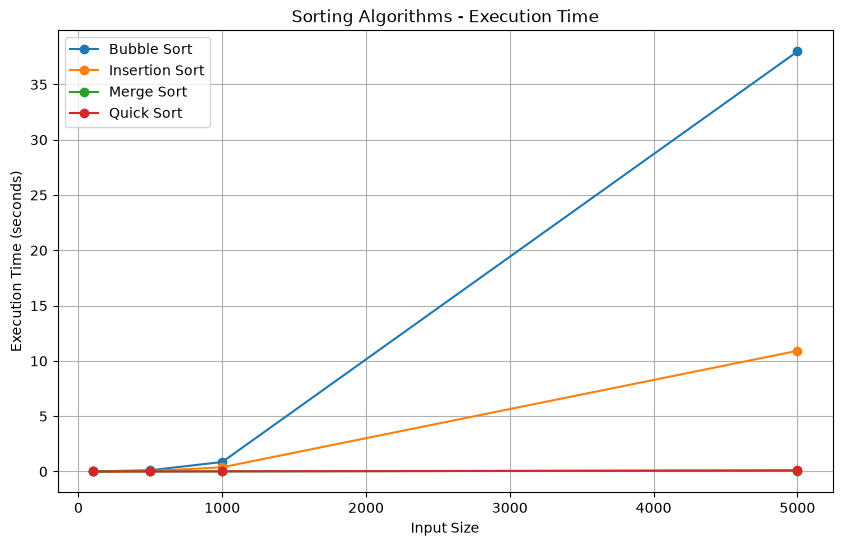

In [27]:
plt.figure(figsize=(10, 6))

for algorithm in results_df["Algorithm"].unique():
    data = results_df[
        (results_df["Algorithm"] == algorithm) &
        (results_df["Condition"] == "Random")
    ]

    plt.plot(
        data["Input Size"],
        data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithms - Execution Time")
plt.legend()
plt.grid(True)

plt.savefig("graphs/sorting_execution_time.png", dpi=300, bbox_inches="tight")
plt.show()

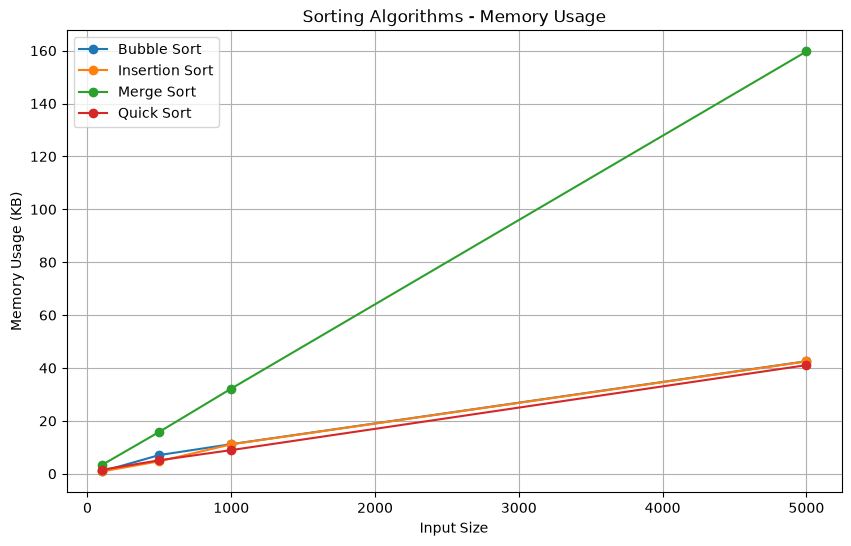

In [28]:
plt.figure(figsize=(10, 6))

for algorithm in results_df["Algorithm"].unique():
    data = results_df[
        (results_df["Algorithm"] == algorithm) &
        (results_df["Condition"] == "Random")
    ]

    plt.plot(
        data["Input Size"],
        data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Memory Usage (KB)")
plt.title("Sorting Algorithms - Memory Usage")
plt.legend()
plt.grid(True)

plt.savefig("graphs/sorting_memory_usage.png", dpi=300, bbox_inches="tight")
plt.show()

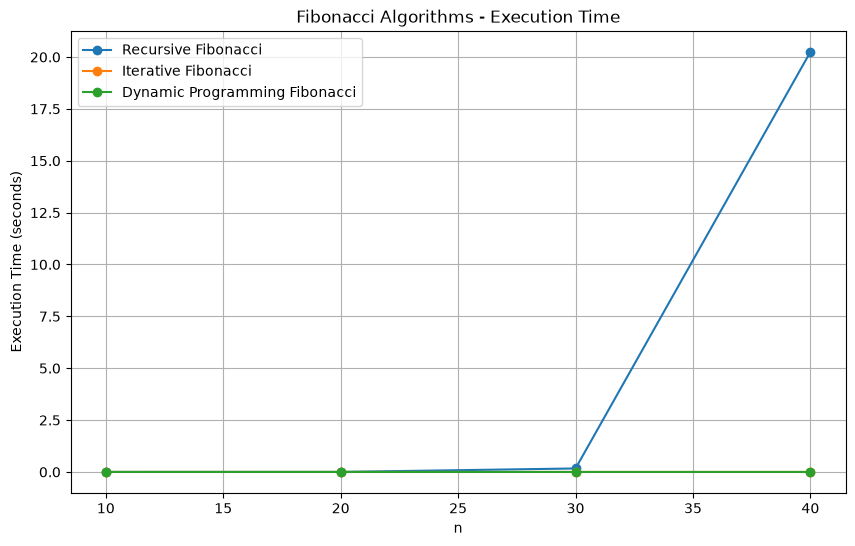

In [29]:
plt.figure(figsize=(10, 6))

for algorithm in fib_df["Algorithm"].unique():
    data = fib_df[fib_df["Algorithm"] == algorithm]

    plt.plot(
        data["n"],
        data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("n")
plt.ylabel("Execution Time (seconds)")
plt.title("Fibonacci Algorithms - Execution Time")
plt.legend()
plt.grid(True)

plt.savefig("graphs/fibonacci_execution_time.png", dpi=300, bbox_inches="tight")
plt.show()

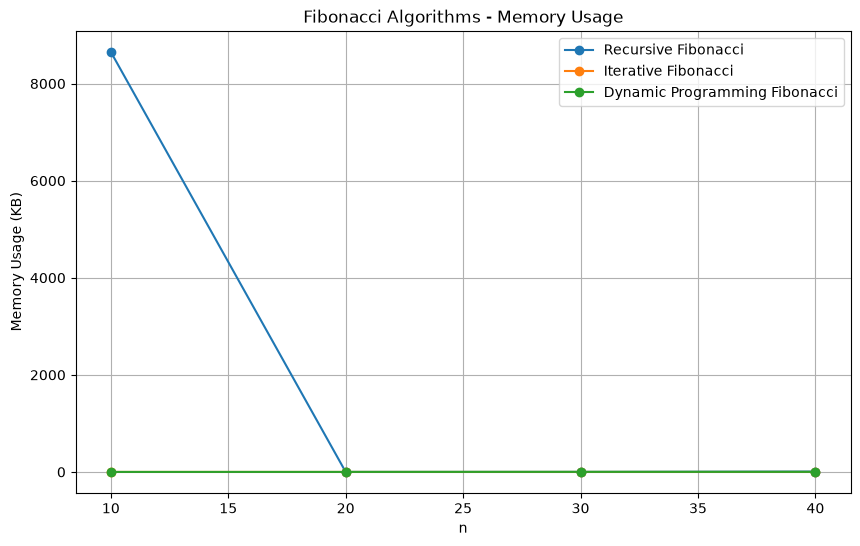

In [30]:
plt.figure(figsize=(10, 6))

for algorithm in fib_df["Algorithm"].unique():
    data = fib_df[fib_df["Algorithm"] == algorithm]

    plt.plot(
        data["n"],
        data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("n")
plt.ylabel("Memory Usage (KB)")
plt.title("Fibonacci Algorithms - Memory Usage")
plt.legend()
plt.grid(True)

plt.savefig("graphs/fibonacci_memory_usage.png", dpi=300, bbox_inches="tight")
plt.show()

# Observations and Analysis

## Sorting Algorithms

1. Bubble Sort and Insertion Sort show quadratic growth for larger input sizes.
2. Merge Sort maintains approximately O(n log n) performance and scales better for large inputs.
3. Quick Sort performs efficiently on random data but can approach O(n²) for sorted or reverse-sorted data when the last element is selected as the pivot.
4. The execution-time graphs show that input size has a significant effect on the performance of quadratic algorithms.
5. Merge Sort generally provides more consistent performance as the input size increases.

## Fibonacci Algorithms

1. Recursive Fibonacci becomes significantly slower as n increases because of its exponential time complexity.
2. Iterative Fibonacci is much faster because it calculates the sequence using a single loop.
3. Dynamic Programming avoids repeated calculations and therefore performs much better than the recursive approach.
4. The experimental results demonstrate the practical difference between exponential and linear-time algorithms.

## Overall Conclusion

The experimental analysis demonstrates that theoretical time and space complexities are useful for predicting how algorithms scale with increasing input size. Algorithms with O(n log n) or O(n) complexity generally scale better than algorithms with O(n²) or exponential complexity.

## Experimental Limitation

The sorting experiment was successfully completed for input sizes up to 5,000 elements. The 10,000-element experiment was attempted but was interrupted because the quadratic sorting algorithms required excessive execution time on the available system. Therefore, no experimental values for the 10,000-element sorting case are reported.